In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt 

## Load X and y

In [2]:
# 1. Load X and y
#    Replace with your actual .npy paths or loading mechanism
X = np.load('X.npy')  # shape: (N, 256, 256)
y = np.load('y.npy') - 1  # shape: (N,)

# 2. Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# 3. Convert to Tensors via a custom Dataset, normalizing each image to [0,1]
class ImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)          # to float32
        # per-image min-max normalization to [0,1]:
        img_min, img_max = img.min(), img.max()
        img = (img - img_min) / (img_max - img_min + 1e-8)
        img = np.expand_dims(img, axis=0)                  # → (1, H, W)
        label = int(self.labels[idx])
        return torch.from_numpy(img), torch.tensor(label, dtype=torch.long)

train_dataset = ImageDataset(X_train, y_train)
test_dataset  = ImageDataset(X_test,  y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# 4. Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Train the model

In [5]:
# 5. Build the model
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=17):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, padding=1),  # → (16,256,256)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (16,128,128)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # → (32,128,128)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (32,64,64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → (64,64,64)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (64,32,32)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
model = CNNClassifier(num_classes=17).to(device)

# 6. Train the model with tqdm progress bar & save the training loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100
train_losses = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    # wrap your DataLoader in tqdm
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", unit="batch")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        # update tqdm bar with current loss
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    #print(f'→ Epoch {epoch} loss: {epoch_loss:.4f}')

# Save model and loss history
torch.save(model.state_dict(), 'cnn_classifier.pth')
torch.save(train_losses, 'train_losses.pt')

print('Training complete. Model and loss history saved.')

Epoch 100/100: 100%|████████████████████████████████████████████████████| 17/17 [00:00<00:00, 48.94batch/s, loss=0.159]


Training complete. Model and loss history saved.


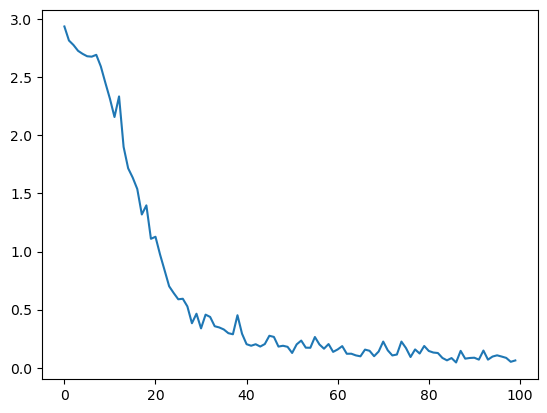

In [15]:
plt.plot(train_losses)

In [18]:
# 7. Compute train & test accuracy
model.eval()  # switch to evaluation mode

@torch.no_grad()
def compute_accuracy(loader):
    correct = 0
    total   = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

train_acc = compute_accuracy(train_loader)
test_acc  = compute_accuracy(test_loader)

print(f'Train Accuracy: {train_acc*100:6.2f}%')
print(f' Test Accuracy: {test_acc*100:6.2f}%')
print(f' Random guess Accuracy: {1/17.*100:6.2f}%')

Train Accuracy: 100.00%
 Test Accuracy:  10.29%
 Random guess Accuracy:   5.88%
